# Grid Resource Allocation with QAOA

 Team baseline: 4 substations, 2 teams, QUBO → Ising → QAOA.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from itertools import product
from scipy.optimize import minimize

from qiskit.circuit.library import QAOAAnsatz
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.primitives import StatevectorEstimator, StatevectorSampler
substations = ["A", "B", "C", "D"]
weights = np.array([4.0, 9.0, 7.0, 5.0])

num_teams = 2
conflicts = [(1, 2)]

p = 4
shots = 2048
seed = 2026

num_nodes = len(substations)
slack_weights = np.array([1.0, 2.0])
num_slack = len(slack_weights)
num_qubits = num_nodes + num_slack


def benefit(x):
    return float(weights @ np.asarray(x, dtype=int))


def feasible(x):
    x = np.asarray(x, dtype=int)
    return (
        x.sum() <= num_teams
        and all(x[i] + x[j] <= 1 for i, j in conflicts)
    )


def selected(x):
    x = np.asarray(x, dtype=int)
    names = [name for name, bit in zip(substations, x) if bit]
    return ", ".join(names) if names else "None"


allocations = list(product([0, 1], repeat=num_nodes))

exact_benefit = max(
    benefit(x) for x in allocations if feasible(x)
)

exact_allocations = {
    x for x in allocations
    if feasible(x) and np.isclose(benefit(x), exact_benefit)
}

## QUBO construction

In [3]:
P_capacity = float(weights.sum() + 1.0)
P_conflict = P_capacity

t = np.r_[np.ones(num_nodes), slack_weights]
rewards = np.r_[weights, np.zeros(num_slack)]

linear = -rewards - 2 * P_capacity * num_teams * t
quadratic = P_capacity * np.outer(t, t)
constant = P_capacity * num_teams**2

for i, j in conflicts:
    quadratic[i, j] += P_conflict / 2
    quadratic[j, i] += P_conflict / 2


def qubo_energy(bits):
    b = np.asarray(bits, dtype=float)
    return float(constant + linear @ b + b @ quadratic @ b)


def encoding_valid(bits):
    bits = np.asarray(bits, dtype=int)
    x = bits[:num_nodes]
    q = bits[num_nodes:]
    return feasible(x) and np.isclose(
        x.sum() + q @ slack_weights,
        num_teams
    )

## QUBO validation

In [4]:
basis_bits = [
    np.array(b, dtype=int)
    for b in product([0, 1], repeat=num_qubits)
]

exact_energy = min(qubo_energy(b) for b in basis_bits)

for b in basis_bits:
    residual = t @ b - num_teams
    expected = (
        -benefit(b[:num_nodes])
        + P_capacity * residual**2
        + P_conflict
        * sum(b[i] * b[j] for i, j in conflicts)
    )
    assert np.isclose(qubo_energy(b), expected)

for x in allocations:
    encoded_energy = min(
        qubo_energy(np.r_[x, q])
        for q in product([0, 1], repeat=num_slack)
    )
    if feasible(x):
        assert np.isclose(encoded_energy, -benefit(x))
    else:
        assert encoded_energy > -benefit(x)

qubo_optima = {
    tuple(b[:num_nodes])
    for b in basis_bits
    if np.isclose(qubo_energy(b), exact_energy)
}

assert qubo_optima == exact_allocations
assert np.isclose(exact_energy, -exact_benefit)

## Ising Hamiltonian

In [5]:
a = linear + np.diag(quadratic)
h = -a / 2
J = {}
offset = float(constant + a.sum() / 2)

for i in range(num_qubits):
    for j in range(i + 1, num_qubits):
        coeff = (quadratic[i, j] + quadratic[j, i]) / 4
        J[i, j] = coeff
        h[i] -= coeff
        h[j] -= coeff
        offset += coeff

pauli_terms = []
pauli_coeffs = []

for i, coeff in enumerate(h):
    label = ["I"] * num_qubits
    label[-1 - i] = "Z"
    pauli_terms.append("".join(label))
    pauli_coeffs.append(float(coeff))

for (i, j), coeff in J.items():
    if not np.isclose(coeff, 0.0):
        label = ["I"] * num_qubits
        label[-1 - i] = "Z"
        label[-1 - j] = "Z"
        pauli_terms.append("".join(label))
        pauli_coeffs.append(float(coeff))

hamiltonian = SparsePauliOp.from_list(
    list(zip(pauli_terms, pauli_coeffs))
).simplify()


def bits_from_index(index):
    return np.array(
        [(index >> k) & 1 for k in range(num_qubits)],
        dtype=int
    )


def decode(bitstring):
    return np.array(
        list(map(int, bitstring[::-1])),
        dtype=int
    )


states = [
    bits_from_index(i)
    for i in range(2**num_qubits)
]

energies = np.array([
    qubo_energy(b)
    for b in states
])

operator = hamiltonian.to_matrix()

assert np.allclose(
    operator,
    np.diag(np.diag(operator))
)

assert np.allclose(
    operator.diagonal().real + offset,
    energies
)

## QAOA setup and optimization

In [6]:
energy_scale = max(
    1.0,
    float(np.max(np.abs(hamiltonian.coeffs)))
)

cost_operator = hamiltonian / energy_scale

ansatz = QAOAAnsatz(
    cost_operator=cost_operator,
    reps=p,
    flatten=True
)

parameters = list(ansatz.parameters)
betas = [v for v in parameters if v.name.startswith("β")]
gammas = [v for v in parameters if v.name.startswith("γ")]

estimator = StatevectorEstimator(default_precision=0.0)


def cost_function(params, history):
    result = estimator.run(
        [(ansatz, [cost_operator], [params])]
    ).result()

    scaled_energy = float(
        np.asarray(result[0].data.evs).reshape(-1)[0]
    )

    history.append(
        scaled_energy * energy_scale + offset
    )

    return scaled_energy


rng = np.random.default_rng(seed)
initial_points = []

for beta, raw_gamma in [
    (0.3, -0.006),
    (0.6, 0.02),
    (1.0, 0.06)
]:
    values = {v: beta for v in betas}
    values.update({
        v: raw_gamma * energy_scale
        for v in gammas
    })
    initial_points.append(
        np.array([values[v] for v in parameters])
    )

for _ in range(3):
    values = {
        v: rng.uniform(0, np.pi)
        for v in betas
    }
    values.update({
        v: rng.uniform(-4, 4)
        for v in gammas
    })
    initial_points.append(
        np.array([values[v] for v in parameters])
    )

results = []
histories = []

for x0 in initial_points:
    history = []
    result = minimize(
        cost_function,
        x0,
        args=(history,),
        method="COBYLA",
        options={
            "maxiter": 1000,
            "rhobeg": 0.25,
            "tol": 1e-5
        }
    )
    results.append(result)
    histories.append(history)

best_run = int(np.argmin([
    r.fun for r in results
]))

best_result = results[best_run]
best_params = best_result.x
mean_energy = (
    best_result.fun * energy_scale + offset
)

## Sampling and metrics

In [7]:
optimized_circuit = ansatz.assign_parameters(
    best_params
)

measured_circuit = optimized_circuit.copy()
measured_circuit.measure_all()

sampler = StatevectorSampler(seed=31415)

counts = (
    sampler
    .run([(measured_circuit,)], shots=shots)
    .result()[0]
    .data.meas
    .get_counts()
)

probabilities = Statevector.from_instruction(
    optimized_circuit
).probabilities()

assert sum(counts.values()) == shots
assert np.isclose(probabilities.sum(), 1.0)
assert np.isclose(
    probabilities @ energies,
    mean_energy
)


sampled_allocations = {
    tuple(decode(bitstring)[:num_nodes])
    for bitstring in counts
}

feasible_samples = [
    x for x in sampled_allocations
    if feasible(x)
]

best_sample = (
    max(feasible_samples, key=benefit)
    if feasible_samples else None
)


masks = {
    "Allocation feasible": np.array([
        feasible(b[:num_nodes])
        for b in states
    ]),
    "Full encoding valid": np.array([
        encoding_valid(b)
        for b in states
    ]),
    "Optimal allocation": np.array([
        tuple(b[:num_nodes]) in exact_allocations
        for b in states
    ]),
    "QUBO ground state": np.isclose(
        energies,
        exact_energy
    )
}

uniform_metrics = np.array([
    mask.mean()
    for mask in masks.values()
])

qaoa_metrics = np.array([
    probabilities @ mask
    for mask in masks.values()
])

measured_metrics = np.array([
    sum(
        count
        for bitstring, count in counts.items()
        if mask[int(bitstring, 2)]
    ) / shots
    for mask in masks.values()
])


allocation_probabilities = {
    x: 0.0
    for x in allocations
}

for bitstring, count in counts.items():
    x = tuple(
        decode(bitstring)[:num_nodes]
    )
    allocation_probabilities[x] += (
        count / shots
    )

## Results

In [8]:
print("Exact optimal allocation:",
      [selected(x) for x in sorted(exact_allocations)])
print("Exact optimal benefit:",
      exact_benefit)
print("QAOA mean energy:",
      round(mean_energy, 4))
print("Exact ground-state energy:",
      exact_energy)

if best_sample is not None:
    print("Best feasible sampled allocation:",
          selected(best_sample))
    print("Best sampled benefit:",
          benefit(best_sample))

print()
print(
    f'{"Metric":24s}'
    f'{"Uniform":>10s}'
    f'{"QAOA":>10s}'
    f'{"Measured":>10s}'
)

for label, u, q, m in zip(
    masks.keys(),
    uniform_metrics,
    qaoa_metrics,
    measured_metrics
):
    print(
        f"{label:24s}"
        f"{u:10.2%}"
        f"{q:10.2%}"
        f"{m:10.2%}"
    )

Exact optimal allocation: ['B, D']
Exact optimal benefit: 14.0
QAOA mean energy: 2.1219
Exact ground-state energy: -14.0
Best feasible sampled allocation: B, D
Best sampled benefit: 14.0

Metric                     Uniform      QAOA  Measured
Allocation feasible         62.50%    91.50%    92.09%
Full encoding valid         15.62%    63.04%    63.09%
Optimal allocation           6.25%     8.32%     8.54%
QUBO ground state            1.56%     6.96%     7.32%


## Convergence plot

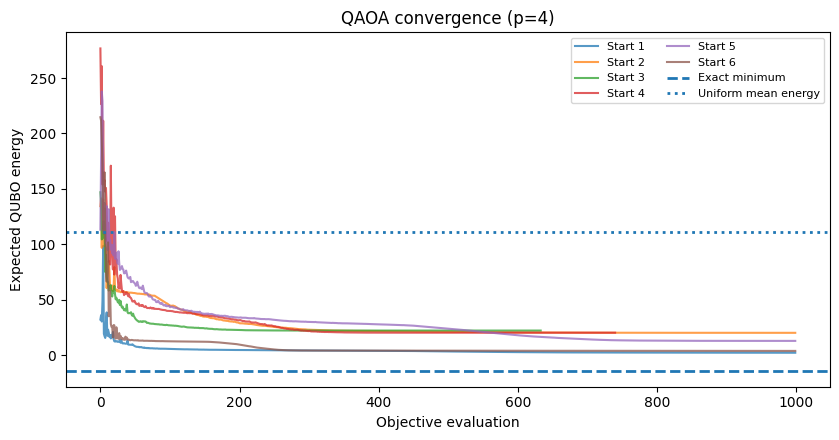

In [9]:
fig, ax = plt.subplots(figsize=(8.5, 4.5))

for run, history in enumerate(histories, 1):
    ax.plot(
        history,
        alpha=0.75,
        label=f"Start {run}"
    )

ax.axhline(
    exact_energy,
    linestyle="--",
    linewidth=2,
    label="Exact minimum"
)

ax.axhline(
    energies.mean(),
    linestyle=":",
    linewidth=2,
    label="Uniform mean energy"
)

ax.set_xlabel("Objective evaluation")
ax.set_ylabel("Expected QUBO energy")
ax.set_title(f"QAOA convergence (p={p})")
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
plt.show()

## Allocation distribution

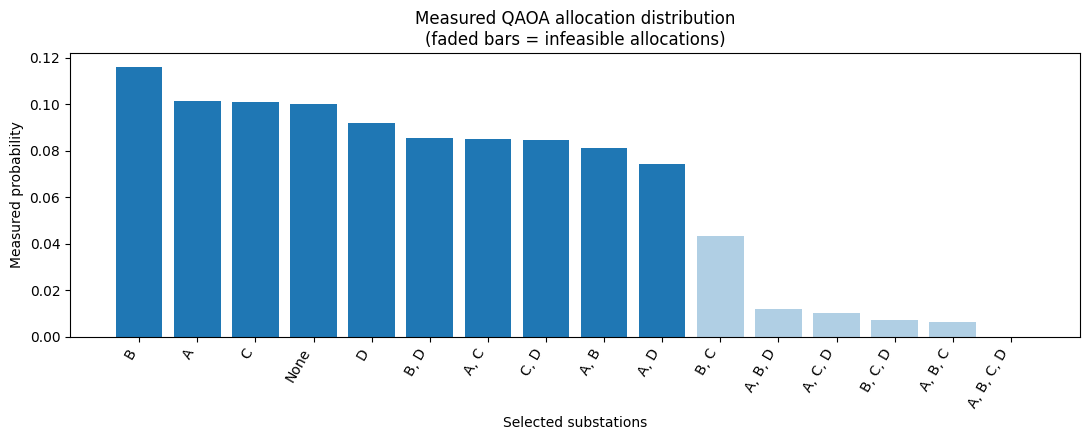

In [10]:
ordered = sorted(
    allocations,
    key=allocation_probabilities.get,
    reverse=True
)

fig, ax = plt.subplots(figsize=(11, 4.5))

bars = ax.bar(
    [selected(x) for x in ordered],
    [allocation_probabilities[x] for x in ordered]
)

for bar, x in zip(bars, ordered):
    if not feasible(x):
        bar.set_alpha(0.35)

ax.set_xlabel("Selected substations")
ax.set_ylabel("Measured probability")
ax.set_title(
    "Measured QAOA allocation distribution\n"
    "(faded bars = infeasible allocations)"
)

plt.setp(
    ax.get_xticklabels(),
    rotation=60,
    ha="right"
)

fig.tight_layout()
plt.show()

## Grid visualization

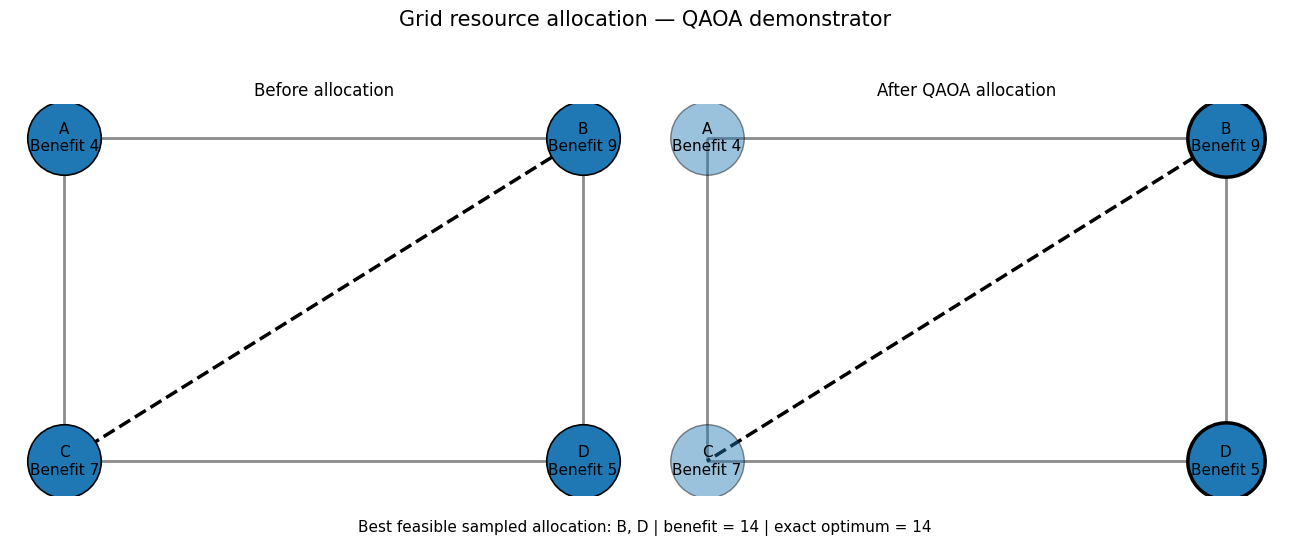

In [11]:
grid_edges = [
    ("A", "B"),
    ("A", "C"),
    ("B", "D"),
    ("C", "D")
]

graph = nx.Graph()
graph.add_nodes_from(substations)
graph.add_edges_from(grid_edges)

pos = {
    "A": (-1.0, 1.0),
    "B": (1.0, 1.0),
    "C": (-1.0, -1.0),
    "D": (1.0, -1.0)
}

labels = {
    node: f"{node}\nBenefit {weights[i]:g}"
    for i, node in enumerate(substations)
}

shown = (
    best_sample
    if best_sample is not None
    else np.zeros(num_nodes, dtype=int)
)

selected_nodes = {
    substations[i]
    for i, bit in enumerate(shown)
    if bit
}

conflict_edges = [
    (substations[i], substations[j])
    for i, j in conflicts
]

fig, axes = plt.subplots(
    1, 2,
    figsize=(13, 5.5)
)

for ax, after in zip(axes, [False, True]):
    nx.draw_networkx_edges(
        graph,
        pos,
        ax=ax,
        edgelist=grid_edges,
        width=2,
        alpha=0.45
    )

    nx.draw_networkx_edges(
        graph,
        pos,
        ax=ax,
        edgelist=conflict_edges,
        width=2.5,
        style="dashed"
    )

    if after:
        unselected = [
            n for n in substations
            if n not in selected_nodes
        ]

        chosen = [
            n for n in substations
            if n in selected_nodes
        ]

        nx.draw_networkx_nodes(
            graph,
            pos,
            ax=ax,
            nodelist=unselected,
            node_size=2800,
            alpha=0.45,
            edgecolors="black",
            linewidths=1.0
        )

        nx.draw_networkx_nodes(
            graph,
            pos,
            ax=ax,
            nodelist=chosen,
            node_size=3100,
            edgecolors="black",
            linewidths=2.5
        )
    else:
        nx.draw_networkx_nodes(
            graph,
            pos,
            ax=ax,
            node_size=2800,
            edgecolors="black",
            linewidths=1.2
        )

    nx.draw_networkx_labels(
        graph,
        pos,
        ax=ax,
        labels=labels,
        font_size=11
    )

    ax.set_title(
        "After QAOA allocation"
        if after
        else "Before allocation"
    )

    ax.axis("off")

caption = (
    f"Best feasible sampled allocation: "
    f"{selected(shown)} | "
    f"benefit = {benefit(shown):g} | "
    f"exact optimum = {exact_benefit:g}"
)

fig.suptitle(
    "Grid resource allocation — QAOA demonstrator",
    fontsize=15
)

fig.text(
    0.5,
    0.03,
    caption,
    ha="center",
    fontsize=11
)

fig.tight_layout(
    rect=[0, 0.07, 1, 0.94]
)

plt.show()